<a href="https://colab.research.google.com/github/GustavoHochgraf/training-eval-overlap/blob/master/notebooks/training_eval_overlap_multilingual_rerun.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Training-Eval Overlap Rerun: Carolina x PoetaV2 (Multilingual Models)

This notebook reruns the same semantic overlap methodology used in the original snapshot, but with multilingual retrieval models that are defensible for Portuguese.

- **Primary recommendation:** `BAAI/bge-m3`
- **Comparison model:** `intfloat/multilingual-e5-large-instruct`
- **Methodology preserved:** Carolina streaming load + PoetaV2 extraction + FAISS nearest-neighbor search + per-task overlap audit.

**Expected runtime:** full runs are still multi-hour experiments on Colab; quick tests remain available through `MAX_CAROLINA_DOCS` and `MAX_INSTANCES_PER_TASK`.


## Experimental Notes

- This notebook is a rerun artifact and should not overwrite the historical snapshot notebook.
- Results are saved into model-specific folders under `../results/runs/`.
- To compare two reruns later, use `scripts/compare_semantic_runs.py` on the output folders.


## Cell 1: Setup & Install

In [1]:
!pip install -q sentence-transformers faiss-cpu datasets pandas tqdm matplotlib seaborn

In [2]:
import os
import re
import json
import time
import unicodedata
from pathlib import Path
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import faiss
import torch
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# Root output directory; the run-specific folders are configured in the next cell.
RESULTS_ROOT = Path('../results/runs')
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")
if DEVICE == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: CPU runtime detected. Full runs will take many hours and may disconnect in Colab.")
    print("In Colab, switch to Runtime > Change runtime type > T4 GPU and rerun from the top.")


c:\Users\gusth\Mestrado\projeto\poetaV2-Analysis\training-eval-overlap\env_eval_overlap\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU


In [3]:
# -- Experiment configuration ------------------------------------------------
# The notebook is configured to run both multilingual models in one pass.
RUN_PROFILES = [
    {
        "slug": "bge_m3",
        "label": "BGE-M3",
        "model_name": "BAAI/bge-m3",
        "query_instruction": None,
        "batch_size_gpu": 16,
        "batch_size_cpu": 1,
    },
    {
        "slug": "multilingual_e5_large_instruct",
        "label": "multilingual-e5-large-instruct",
        "model_name": "intfloat/multilingual-e5-large-instruct",
        "query_instruction": "Given a search query, retrieve relevant passages from the training corpus that may overlap with the query",
        "batch_size_gpu": 8,
        "batch_size_cpu": 1,
    },
]

ALLOW_CPU_RUN = False  # Only enable for tiny smoke tests.

for profile in RUN_PROFILES:
    profile['batch_size'] = profile['batch_size_gpu'] if DEVICE == 'cuda' else profile['batch_size_cpu']

if DEVICE != 'cuda' and not ALLOW_CPU_RUN:
    raise RuntimeError(
        "GPU runtime required for the full experiment. In Colab, switch to Runtime > Change runtime type > T4 GPU and rerun from the top. If you only want a smoke test on CPU, set ALLOW_CPU_RUN = True and keep MAX_CAROLINA_DOCS small."
    )

MAX_CAROLINA_DOCS = 1000        # Quick test: 1000 docs. Set to None for full run on GPU.
SIMILARITY_THRESHOLD = 0.85     # Cosine similarity threshold for "overlap"
TOP_K = 5                       # Nearest neighbors per query
MIN_DOC_LENGTH = 50             # Minimum character length for Carolina docs
MAX_INSTANCES_PER_TASK = 500    # Cap per task to limit RAM. Set to None for all instances.
MODEL_MAX_SEQ_LENGTH = 512      # bge-m3 defaults to 8192 tokens; a smaller cap is much faster on 8 GB GPUs.
MAX_DOCUMENT_CHARS = 2000       # Pre-truncate Carolina docs before tokenization to avoid huge batches.
BOOTSTRAP_N = 10_000
BOOTSTRAP_CI = 0.95

RUN_OUTPUT_ROOT = RESULTS_ROOT
RUN_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print("Configured runs:")
for profile in RUN_PROFILES:
    print(f"  - {profile['label']}: {profile['model_name']} | batch_size={profile['batch_size']}")
print(f"Results root: {RUN_OUTPUT_ROOT.resolve()}")
print(f"Sequence cap: {MODEL_MAX_SEQ_LENGTH} tokens | Document cap: {MAX_DOCUMENT_CHARS:,} chars")
print("Note: Carolina docs are very long in raw form; local reruns use truncation for throughput. Record these settings when reporting results.")
print("Note: seeing 'Using FAISS CPU index' is acceptable for ~1k docs; the main bottleneck is model encoding, not FAISS search.")


Configured runs:
  - BGE-M3: BAAI/bge-m3 | batch_size=16
  - multilingual-e5-large-instruct: intfloat/multilingual-e5-large-instruct | batch_size=8
Results root: C:\Users\gusth\Mestrado\projeto\poetaV2-Analysis\training-eval-overlap\results\runs
Sequence cap: 512 tokens | Document cap: 2,000 chars
Note: Carolina docs are very long in raw form; local reruns use truncation for throughput. Record these settings when reporting results.
Note: seeing 'Using FAISS CPU index' is acceptable for ~1k docs; the main bottleneck is model encoding, not FAISS search.


In [4]:
# -- Model-specific text formatting -----------------------------------------
def format_query_for_profile(text: str, profile: dict) -> str:
    query_instruction = profile.get("query_instruction")
    if query_instruction:
        return f"Instruct: {query_instruction}\nQuery: {text}"
    return text


def format_document_for_profile(text: str, profile: dict) -> str:
    if MAX_DOCUMENT_CHARS is not None and len(text) > MAX_DOCUMENT_CHARS:
        return text[:MAX_DOCUMENT_CHARS]
    return text


## Cell 2: Download Carolina Corpus

In [5]:
from huggingface_hub import login
from pathlib import Path as _Path

def _load_env(path):
    """Read KEY=VALUE lines from a .env file, return dict."""
    env = {}
    try:
        for line in _Path(path).read_text(encoding="utf-8").splitlines():
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            key, _, value = line.partition("=")
            env[key.strip()] = value.strip()
    except FileNotFoundError:
        pass
    return env

# 1. Try local .env file (one level up from notebooks/)
HF_TOKEN = _load_env("../.env").get("HF_TOKEN")

# 2. Try Colab secrets
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_TOKEN")
    except Exception:
        pass

# 3. Try environment variable
if not HF_TOKEN:
    HF_TOKEN = os.environ.get("HF_TOKEN")

# 4. Last resort: interactive login
if HF_TOKEN:
    login(token=HF_TOKEN)
    print("Logged in with HF_TOKEN!")
else:
    print("No HF_TOKEN found.")
    print("Tip: On Colab, add HF_TOKEN to Secrets (key icon in left sidebar) to avoid pasting every time.")
    print("     Locally, create training-eval-overlap/.env with: HF_TOKEN=hf_xxx")
    from huggingface_hub import notebook_login
    notebook_login()

Logged in with HF_TOKEN!


In [6]:
print("Loading Carolina corpus from g4me/corpus-carolina-v2...")
try:
    # Load the suggested dataset repository using the correct split 'corpus'
    dataset = load_dataset("g4me/corpus-carolina-v2", split="corpus", streaming=True)

    carolina_texts = []
    carolina_meta = []

    for i, example in enumerate(tqdm(dataset, desc="Loading Carolina")):
        if MAX_CAROLINA_DOCS is not None and i >= MAX_CAROLINA_DOCS:
            break

        text = example.get("text", "") or ""
        text_str = str(text).strip()
        if len(text_str) < MIN_DOC_LENGTH:
            continue

        carolina_texts.append(text_str)
        carolina_meta.append({
            "doc_id": str(i),
            "domain": example.get("taxonomy", "unknown"),
            "length": len(text_str),
        })

    print(f"\nCarolina corpus loaded: {len(carolina_texts):,} documents")
    carolina_lengths = np.array([meta['length'] for meta in carolina_meta], dtype=np.int32)
    print(f"Raw document length stats (chars): p50={np.percentile(carolina_lengths, 50):.0f}, p95={np.percentile(carolina_lengths, 95):.0f}, max={carolina_lengths.max():.0f}")
    if MAX_DOCUMENT_CHARS is not None:
        truncated_docs = int((carolina_lengths > MAX_DOCUMENT_CHARS).sum())
        print(f"Embedding cap active: first {MAX_DOCUMENT_CHARS:,} chars | truncated docs: {truncated_docs}/{len(carolina_lengths)}")

except Exception as e:
    print(f"Failed to load from g4me/corpus-carolina-v2: {e}")

Loading Carolina corpus from g4me/corpus-carolina-v2...


Loading Carolina: 1000it [00:02, 466.13it/s]


Carolina corpus loaded: 993 documents
Raw document length stats (chars): p50=13831, p95=44052, max=84931
Embedding cap active: first 2,000 chars | truncated docs: 987/993


## Cell 3: Download & Extract PoetaV2 Tasks

In [7]:
# Clone the PoetaV2 repository
!rm -rf /content/PoETaV2
!git clone --depth 1 https://github.com/PoETaV2/PoETaV2.git /content/PoETaV2
print("\nPoetaV2 repo cloned.")
!ls /content/PoETaV2/

'rm' n�o � reconhecido como um comando interno
ou externo, um programa oper�vel ou um arquivo em lotes.



PoetaV2 repo cloned.


fatal: destination path '/content/PoETaV2' already exists and is not an empty directory.
'ls' n�o � reconhecido como um comando interno
ou externo, um programa oper�vel ou um arquivo em lotes.


In [8]:
# ── Task Source Registry ───────────────────────────────────────────────────
# Static mapping of every PoETaV2 evaluation task to its data source.
# Three source types: "hf" (HuggingFace datasets), "bigbench" (GitHub JSON),
# "custom" (per-task download logic).

import urllib.request
import csv
import io
import time
import gzip

poetav2_root = Path("/content/PoETaV2")

BIGBENCH_BASE_URL = (
    "https://raw.githubusercontent.com/ZanezZephyrs/"
    "temp_big_bench_json_tasks/refs/heads/main/tasks/"
)

TASK_SOURCES = {
    # ── HuggingFace tasks ──────────────────────────────────────────────────
    "assin_rte_greedy": {
        "type": "hf", "dataset_id": "assin2", "split": "test",
        "text_fields": {"question": "premise", "context": "hypothesis"},
    },
    "assin_sts_greedy": {
        "type": "hf", "dataset_id": "assin2", "split": "test",
        "text_fields": {"question": "premise", "context": "hypothesis"},
    },
    "agnews_pt_greedy": {
        "type": "hf", "dataset_id": "maritaca-ai/ag_news_pt", "split": "test",
        "text_fields": {"question": "title", "context": "text"},
    },
    "boolq_pt_greedy": {
        "type": "hf", "dataset_id": "maritaca-ai/boolq_pt", "split": "validation",
        "text_fields": {"question": "question", "context": "passage"},
    },
    "imdb_pt_greedy": {
        "type": "hf", "dataset_id": "maritaca-ai/imdb_pt", "split": "test",
        "text_fields": {"question": "text"},
    },
    "sst2_pt_greedy": {
        "type": "hf", "dataset_id": "maritaca-ai/sst2_pt", "split": "validation",
        "text_fields": {"question": "text"},
    },
    "arc_challenge_greedy_pt": {
        "type": "hf", "dataset_id": "marlosb/ai2_arc-pt", "split": "test",
        "config": "ARC-Challenge",
        "text_fields": {"question": "question", "choices": "choices"},
    },
    "arc_easy_greedy_pt": {
        "type": "hf", "dataset_id": "marlosb/ai2_arc-pt", "split": "test",
        "config": "ARC-Easy",
        "text_fields": {"question": "question", "choices": "choices"},
    },
    "bluex_launch_version_": {
        "type": "hf", "dataset_id": "portuguese-benchmark-datasets/BLUEX",
        "split": "questions",
        "text_fields": {"question": "question"},
    },
    "storycloze_pt_greedy": {
        "type": "hf",
        "dataset_id": "portuguese-benchmark-datasets/story_cloze_pt",
        "split": "eval",
        "text_fields": {
            "context": ["input_sentence_1", "input_sentence_2",
                        "input_sentence_3", "input_sentence_4"],
            "question": "quiz1",
        },
    },
    "hatebr_binary_greedy": {
        "type": "hf", "dataset_id": "ruanchaves/hatebr", "split": "test",
        "text_fields": {"question": "instagram_comments"},
    },
    "enem_greedy": {
        "type": "hf", "dataset_id": "maritaca-ai/enem", "split": "train",
        "config": "2022",
        "text_fields": {"question": "question"},
    },
    "enem_2022_greedy": {
        "type": "hf", "dataset_id": "maritaca-ai/enem", "split": "train",
        "config": "2022",
        "text_fields": {"question": "question"},
    },
    "tweetsentbr_greedy": {
        "type": "hf", "dataset_id": "eduagarcia/tweetsentbr_fewshot", "split": "test",
        "text_fields": {"question": "sentence"},
    },
    "massive_greedy": {
        "type": "hf", "dataset_id": "AmazonScience/massive", "split": "test",
        "config": "pt-BR",
        "text_fields": {"question": "utt"},
    },

    # ── BigBench JSON tasks ────────────────────────────────────────────────
    # URL pattern: tasks/{DirName}/task.json (case-sensitive directory names)
    "broverbs_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "BRoverbs/task.json",
    },
    "broverbs_mc_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "BRoverbs_proverb_to_history/task.json",
    },
    "bigbench_pt_analogical_similarity_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "analogical_similarity/task.json",
    },
    "bigbench_pt_code_line_description_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "code_line_description/task.json",
    },
    "bigbench_pt_empirical_judgments_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "empirical_judgments/task.json",
    },
    "bigbench_pt_formal_fallacies_syllogisms_negation_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "formal_fallacies_syllogisms_negation/task.json",
    },
    "bigbench_pt_general_knowledge_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "general_knowledge/task.json",
    },
    "bigbench_pt_mathematical_induction_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "mathematical_induction/task.json",
    },
    "bigbench_pt_simple_ethical_questions_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "simple_ethical_questions/task.json",
    },
    "bigbench_pt_strategyqa_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "strategyqa/task.json",
    },
    "bigbench_pt_vitaminc_fact_verification_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "vitaminc_fact_verification/task.json",
    },
    "bigbench_pt_causal_judgment_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "causal_judgment/task.json",
    },
    "bigbench_pt_cause_and_effect_two_sentences_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "cause_and_effect_two_sentences/task.json",
    },
    "bigbench_pt_social_iqa_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "social_iqa/task.json",
    },
    "bigbench_pt_bbq_greedy": {
        "type": "bigbench",
        "json_url": [
            BIGBENCH_BASE_URL + "bbq/age_disambig/task.json",
            BIGBENCH_BASE_URL + "bbq/disability_status_disambig/task.json",
            BIGBENCH_BASE_URL + "bbq/gender_identity_disambig/task.json",
            BIGBENCH_BASE_URL + "bbq/nationality_disambig/task.json",
            BIGBENCH_BASE_URL + "bbq/physical_appearance_disambig/task.json",
            BIGBENCH_BASE_URL + "bbq/race_ethnicity_disambig/task.json",
            BIGBENCH_BASE_URL + "bbq/religion_disambig/task.json",
        ],
    },
    "ethics_commonsense_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "ethics_commonsense_test_hard/task.json",
    },
    "inferbr_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "inferbr/task.json",
    },
    "repro_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "repro/task.json",
    },
    "mina_br_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "MinaBR/task.json",
    },
    "math_mc_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "Math-mc/task.json",
    },
    "gsm8k_mc_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "gsm8k-mc/task.json",
    },
    "agieval_sat_math_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "sat_math/task.json",
    },
    "balanced_copa_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "balanced_copa/task.json",
    },
    "logiqa_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "logiQA/task.json",
    },

    # ── Custom tasks ───────────────────────────────────────────────────────
    "faquad_greedy": {
        "type": "custom",
        "handler": "faquad",
    },
    "mkqa_greedy": {
        "type": "custom",
        "handler": "mkqa",
    },
    "wsc285_pt_greedy": {
        "type": "custom",
        "handler": "wsc285_pt",
    },
    "pt_hate_speech_greedy": {
        "type": "custom",
        "handler": "pt_hate_speech",
    },
}

print(f"Task registry: {len(TASK_SOURCES)} tasks")
by_type = {}
for cfg in TASK_SOURCES.values():
    by_type[cfg["type"]] = by_type.get(cfg["type"], 0) + 1
for t, n in sorted(by_type.items()):
    print(f"  {t}: {n}")

Task registry: 43 tasks
  bigbench: 24
  custom: 4
  hf: 15


In [9]:
# ── Three Loader Functions ─────────────────────────────────────────────────

def load_hf_task(task_name, cfg):
    """Load a task from HuggingFace datasets. Returns list[EvalInstance]."""
    try:
        kwargs = {
            "path": cfg["dataset_id"],
            "split": cfg["split"],
            "trust_remote_code": True,
        }
        if "config" in cfg:
            kwargs["name"] = cfg["config"]

        ds = load_dataset(**kwargs)
        instances = []
        text_fields = cfg["text_fields"]

        for idx, example in enumerate(ds):
            question = ""
            context = ""
            answer = ""
            choices = []

            # Extract question field
            if "question" in text_fields:
                col = text_fields["question"]
                if isinstance(col, str):
                    question = str(example.get(col, ""))
                elif isinstance(col, list):
                    question = " ".join(str(example.get(c, "")) for c in col)

            # Extract context field (can be a single column or list of columns)
            if "context" in text_fields:
                col = text_fields["context"]
                if isinstance(col, list):
                    context = " ".join(str(example.get(c, "")) for c in col)
                else:
                    context = str(example.get(col, ""))

            # Extract choices (ARC format: nested dict with "text" and "label")
            if "choices" in text_fields:
                col = text_fields["choices"]
                raw = example.get(col, [])
                if isinstance(raw, dict) and "text" in raw:
                    choices = [str(t) for t in raw["text"]]
                elif isinstance(raw, list):
                    choices = [str(c) for c in raw]

            # Extract answer/label
            raw_answer = example.get("answer", example.get("label",
                         example.get("answerKey", "")))
            answer = str(raw_answer) if raw_answer is not None else ""

            inst = EvalInstance(
                task_name=task_name,
                instance_id=f"{task_name}_{idx}",
                split=cfg["split"],
                question=question,
                context=context,
                answer=answer,
                choices=choices,
            )
            if len(inst.search_text) >= MIN_DOC_LENGTH:
                instances.append(inst)

        return instances

    except Exception as e:
        print(f"    [WARN] {task_name}: {e}")
        return []


def _download_json(url):
    """Download and parse a JSON file from a URL."""
    req = urllib.request.Request(url, headers={"User-Agent": "PoETaV2-Analysis/1.0"})
    with urllib.request.urlopen(req, timeout=30) as resp:
        return json.loads(resp.read().decode("utf-8"))


def load_bigbench_task(task_name, cfg):
    """Load a BigBench-format JSON task. Returns list[EvalInstance]."""
    try:
        urls = cfg["json_url"]
        if isinstance(urls, str):
            urls = [urls]

        all_examples = []
        for url in urls:
            data = _download_json(url)
            all_examples.extend(data.get("examples", []))
            time.sleep(0.2)  # rate-limit politeness

        instances = []
        for idx, ex in enumerate(all_examples):
            question = str(ex.get("input", ""))
            target_scores = ex.get("target_scores", {})
            choices = list(target_scores.keys()) if target_scores else []
            # Answer is the key with score == 1
            answer = ""
            for k, v in target_scores.items():
                if v == 1:
                    answer = k
                    break

            # For tasks with empty input (e.g. cause_and_effect), use
            # the choices as the question text
            if not question.strip() and choices:
                question = " / ".join(choices)

            inst = EvalInstance(
                task_name=task_name,
                instance_id=f"{task_name}_{idx}",
                split="test",
                question=question,
                answer=answer,
                choices=choices,
            )
            if len(inst.search_text) >= MIN_DOC_LENGTH:
                instances.append(inst)

        return instances

    except Exception as e:
        print(f"    [WARN] {task_name}: {e}")
        return []


def load_custom_task(task_name, cfg, poetav2_root):
    """Load a custom task with per-task logic. Returns list[EvalInstance]."""
    handler = cfg["handler"]
    instances = []

    try:
        if handler == "faquad":
            url = ("https://raw.githubusercontent.com/liafacom/faquad/"
                   "master/data/dataset.json")
            data = _download_json(url)
            idx = 0
            for article in data.get("data", []):
                for para in article.get("paragraphs", []):
                    context = para.get("context", "")
                    for qa in para.get("qas", []):
                        question = qa.get("question", "")
                        answers = qa.get("answers", [])
                        answer = answers[0]["text"] if answers else ""
                        inst = EvalInstance(
                            task_name=task_name,
                            instance_id=f"{task_name}_{idx}",
                            split="test",
                            question=question,
                            context=context,
                            answer=answer,
                        )
                        if len(inst.search_text) >= MIN_DOC_LENGTH:
                            instances.append(inst)
                        idx += 1

        elif handler == "mkqa":
            # MKQA is a gzipped JSONL file
            url = ("https://raw.githubusercontent.com/apple/ml-mkqa/"
                   "main/dataset/mkqa.jsonl.gz")
            req = urllib.request.Request(url, headers={
                "User-Agent": "PoETaV2-Analysis/1.0"})
            with urllib.request.urlopen(req, timeout=120) as resp:
                raw = gzip.decompress(resp.read())
            for line in raw.decode("utf-8").splitlines():
                if not line.strip():
                    continue
                row = json.loads(line)
                queries = row.get("queries", {})
                answers = row.get("answers", {})
                pt_query = queries.get("pt", "")
                pt_answers = answers.get("pt", [])
                answer_text = ""
                if pt_answers and isinstance(pt_answers, list):
                    first = pt_answers[0]
                    if isinstance(first, dict):
                        answer_text = str(first.get("text", ""))
                    else:
                        answer_text = str(first)

                if pt_query:
                    inst = EvalInstance(
                        task_name=task_name,
                        instance_id=f"{task_name}_{len(instances)}",
                        split="test",
                        question=pt_query,
                        answer=answer_text,
                    )
                    if len(inst.search_text) >= MIN_DOC_LENGTH:
                        instances.append(inst)

        elif handler == "wsc285_pt":
            url = ("https://raw.githubusercontent.com/gabimelo/portuguese_wsc/"
                   "master/data/processed/portuguese_wsc.json")
            data = _download_json(url)
            items = data if isinstance(data, list) else data.get(
                "data", data.get("examples", []))
            for idx, item in enumerate(items):
                if isinstance(item, dict):
                    text = item.get("text", item.get("sentence", str(item)))
                    answer = str(item.get("answer", item.get("label", "")))
                else:
                    text = str(item)
                    answer = ""
                inst = EvalInstance(
                    task_name=task_name,
                    instance_id=f"{task_name}_{idx}",
                    split="test",
                    question=str(text),
                    answer=answer,
                )
                if len(inst.search_text) >= MIN_DOC_LENGTH:
                    instances.append(inst)

        elif handler == "pt_hate_speech":
            url = ("https://raw.githubusercontent.com/paulafortuna/"
                   "Portuguese-Hate-Speech-Dataset/master/"
                   "2019-05-28_portuguese_hate_speech_binary_classification.csv")
            req = urllib.request.Request(url, headers={
                "User-Agent": "PoETaV2-Analysis/1.0"})
            with urllib.request.urlopen(req, timeout=30) as resp:
                content = resp.read().decode("utf-8")
            reader = csv.DictReader(io.StringIO(content))
            for idx, row in enumerate(reader):
                text = row.get("text", "")
                inst = EvalInstance(
                    task_name=task_name,
                    instance_id=f"{task_name}_{idx}",
                    split="test",
                    question=str(text),
                    answer=str(row.get("hatespeech_comb", "")),
                )
                if len(inst.search_text) >= MIN_DOC_LENGTH:
                    instances.append(inst)

        else:
            print(f"    [WARN] {task_name}: unknown handler '{handler}'")

    except Exception as e:
        print(f"    [WARN] {task_name}: {e}")

    return instances

print("Loader functions defined: load_hf_task, load_bigbench_task, load_custom_task")

Loader functions defined: load_hf_task, load_bigbench_task, load_custom_task


In [10]:
@dataclass
class EvalInstance:
    """A single evaluation instance from a PoetaV2 task."""
    task_name: str
    instance_id: str
    split: str = "test"
    question: str = ""
    context: str = ""
    answer: str = ""
    choices: list = field(default_factory=list)

    @property
    def search_text(self) -> str:
        """Concatenate question + context for embedding search."""
        parts = [self.question, self.context]
        return " ".join(p for p in parts if p.strip())

    @property
    def all_text_fields(self) -> list:
        fields = [self.question, self.context, self.answer] + self.choices
        return [f for f in fields if f.strip()]

In [11]:
# ── Load All PoETaV2 Tasks ─────────────────────────────────────────────────

import random

LOADERS = {
    "hf": lambda name, cfg: load_hf_task(name, cfg),
    "bigbench": lambda name, cfg: load_bigbench_task(name, cfg),
    "custom": lambda name, cfg: load_custom_task(name, cfg, poetav2_root),
}

all_instances = []
failed_tasks = []

print(f"Loading {len(TASK_SOURCES)} tasks...")
if MAX_INSTANCES_PER_TASK:
    print(f"  (capped at {MAX_INSTANCES_PER_TASK} instances per task)\n")

for task_name, cfg in TASK_SOURCES.items():
    loader = LOADERS[cfg["type"]]
    instances = loader(task_name, cfg)

    # Cap instances per task to limit memory
    if instances and MAX_INSTANCES_PER_TASK and len(instances) > MAX_INSTANCES_PER_TASK:
        random.seed(42)
        instances = random.sample(instances, MAX_INSTANCES_PER_TASK)

    if instances:
        all_instances.extend(instances)
        print(f"  {task_name}: {len(instances)} instances")
    else:
        failed_tasks.append(task_name)
        print(f"  {task_name}: 0 instances (FAILED)")

eval_instances = all_instances

print(f"\n{'='*60}")
print(f"Total: {len(eval_instances):,} evaluation instances from "
      f"{len(TASK_SOURCES) - len(failed_tasks)}/{len(TASK_SOURCES)} tasks")

if failed_tasks:
    print(f"\nFailed tasks ({len(failed_tasks)}):")
    for t in failed_tasks:
        print(f"  - {t}")

# Build DataFrame for display
instance_df = pd.DataFrame([
    {"task_name": i.task_name, "instance_id": i.instance_id,
     "question": i.question[:100], "context": i.context[:100],
     "answer": str(i.answer)[:50]}
    for i in eval_instances
])

# Per-task counts
if len(instance_df) > 0:
    task_counts = instance_df['task_name'].value_counts().sort_index()
    print(f"\n{len(task_counts)} tasks loaded:")
    print(task_counts.to_string())
else:
    task_counts = pd.Series(dtype=int)
    print("\nWARNING: No instances loaded. Check errors above.")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'assin2' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading 43 tasks...
  (capped at 500 instances per task)



`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'assin2' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


  assin_rte_greedy: 500 instances


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'maritaca-ai/ag_news_pt' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


...

  enem_greedy: 180 instances


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'eduagarcia/tweetsentbr_fewshot' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


  enem_2022_greedy: 180 instances


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'AmazonScience/massive' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


  tweetsentbr_greedy: 500 instances
    [WARN] massive_greedy: Dataset scripts are no longer supported, but found massive.py
  massive_greedy: 0 instances (FAILED)
  broverbs_greedy: 194 instances
  broverbs_mc_greedy: 27 instances
  bigbench_pt_analogical_similarity_greedy: 300 instances
  bigbench_pt_code_line_description_greedy: 44 instances
  bigbench_pt_empirical_judgments_greedy: 39 instances
  bigbench_pt_formal_fallacies_syllogisms_negation_greedy: 300 instances
  bigbench_pt_general_knowledge_greedy: 14 instances
  bigbench_pt_mathematical_induction_greedy: 68 instances
  bigbench_pt_simple_ethical_questions_greedy: 115 instances
  bigbench_pt_strategyqa_greedy: 216 instances
  bigbench_pt_vitaminc_fact_verification_greedy: 300 instances
  bigbench_pt_causal_judgment_greedy: 190 instances
  bigbench_pt_cause_and_effect_two_sentences_greedy: 42 instances
  bigbench_pt_social_iqa_greedy: 300 instances
  bigbench_pt_bbq_greedy: 500 instances
  ethics_commonsense_greedy: 216 insta

## Cell 4: Run Both Multilingual Experiments

This section executes the same overlap pipeline twice, once for `bge-m3` and once for `multilingual-e5-large-instruct`, while keeping the rest of the methodology unchanged.


In [12]:
# -- Shared helpers for both model runs ------------------------------------
def bootstrap_ci(contaminated, total, n_bootstrap=10_000, ci=0.95, seed=42):
    if total == 0:
        return 0.0, 0.0, 0.0
    rng = np.random.default_rng(seed)
    labels = np.array([1] * contaminated + [0] * (total - contaminated))
    boot_rates = np.array([
        rng.choice(labels, size=total, replace=True).mean()
        for _ in range(n_bootstrap)
    ])
    alpha = (1 - ci) / 2
    return (
        contaminated / total,
        float(np.percentile(boot_rates, 100 * alpha)),
        float(np.percentile(boot_rates, 100 * (1 - alpha))),
    )


def build_faiss_index_incremental(texts, model, profile, batch_size=64, chunk_size=50_000):
    dim = model.get_sentence_embedding_dimension()

    try:
        res = faiss.StandardGpuResources()
        index_flat = faiss.IndexFlatIP(dim)
        index = faiss.index_cpu_to_gpu(res, 0, index_flat)
        print("Using FAISS GPU index")
    except Exception:
        index = faiss.IndexFlatIP(dim)
        print("Using FAISS CPU index")

    n_chunks = (len(texts) + chunk_size - 1) // chunk_size

    for chunk_idx in range(n_chunks):
        start = chunk_idx * chunk_size
        end = min(start + chunk_size, len(texts))
        chunk_texts = texts[start:end]
        chunk_lengths = np.array([len(text) for text in chunk_texts], dtype=np.int32)
        formatted_chunk_texts = [format_document_for_profile(text, profile) for text in chunk_texts]

        print(f"\nEncoding chunk {chunk_idx + 1}/{n_chunks} ({start:,}-{end:,})...")
        print(f"  Raw chars: p50={np.percentile(chunk_lengths, 50):.0f}, p95={np.percentile(chunk_lengths, 95):.0f}, max={chunk_lengths.max():.0f}")
        if MAX_DOCUMENT_CHARS is not None:
            truncated_docs = int((chunk_lengths > MAX_DOCUMENT_CHARS).sum())
            print(f"  Applying cap: {MAX_DOCUMENT_CHARS:,} chars ({truncated_docs}/{len(chunk_lengths)} docs truncated)")
        chunk_start_time = time.perf_counter()
        embeddings = model.encode(
            formatted_chunk_texts,
            batch_size=batch_size,
            show_progress_bar=True,
            normalize_embeddings=True,
        )
        embeddings = np.array(embeddings, dtype=np.float32)
        index.add(embeddings)
        print(f"  Chunk encode time: {time.perf_counter() - chunk_start_time:.1f}s")
        print(f"  Index size: {index.ntotal:,} vectors")

    return index


def generate_latex_table(summary_df, results_df, profile, n_bootstrap=10_000, ci=0.95):
    latex_row_end = "\\"
    lines = [
        r"\begin{table}[ht]",
        r"\centering",
        f"\caption{{Semantic overlap rates ({profile['label']}): Carolina corpus $\times$ PoetaV2 benchmarks.}}",
        f"\label{{tab:semantic-overlap-{profile['slug']}}}",
        r"\begin{tabular}{lrrrr}",
        r"\toprule",
        "Task & $N$ & Overlap (\%) & Mean Sim & 95\% CI " + latex_row_end,
        r"\midrule",
    ]

    for _, row in summary_df.iterrows():
        task = row["Task"].replace("_", r"\_")
        lines.append(
            f"{task} & {row['Total']:.0f} & "
            f"{row['Rate (%)']:.1f} & {row['Mean Sim']:.3f} & "
            f"[{row['CI Lower']:.1f}, {row['CI Upper']:.1f}] " + latex_row_end
        )

    total_n = results_df.shape[0]
    total_overlap = results_df["overlap"].sum()
    rate = total_overlap / total_n * 100 if total_n else 0
    mean_sim = results_df["top1_similarity"].mean()
    _, ci_lo, ci_hi = bootstrap_ci(int(total_overlap), total_n, n_bootstrap, ci)

    lines.append(r"\midrule")
    lines.append(
        f"\textbf{{Overall}} & {total_n} & "
        f"{rate:.1f} & {mean_sim:.3f} & "
        f"[{ci_lo * 100:.1f}, {ci_hi * 100:.1f}] " + latex_row_end
    )

    lines += [
        r"\bottomrule",
        r"\end{tabular}",
        r"\end{table}",
    ]
    return "\n".join(lines)


def build_markdown_comparison(run_artifacts):
    baseline = run_artifacts[RUN_PROFILES[0]['slug']]
    candidate = run_artifacts[RUN_PROFILES[1]['slug']]

    baseline_pairs = list(zip(baseline['results_df']['task_name'], baseline['results_df']['instance_id'], baseline['results_df']['overlap']))
    candidate_pairs = list(zip(candidate['results_df']['task_name'], candidate['results_df']['instance_id'], candidate['results_df']['overlap']))
    baseline_keys = {(task, instance_id) for task, instance_id, is_overlap in baseline_pairs if is_overlap}
    candidate_keys = {(task, instance_id) for task, instance_id, is_overlap in candidate_pairs if is_overlap}

    common = baseline_keys & candidate_keys
    baseline_only = baseline_keys - candidate_keys
    candidate_only = candidate_keys - baseline_keys

    baseline_summary = baseline['summary_export_df'].set_index('task')
    candidate_summary = candidate['summary_export_df'].set_index('task')
    task_names = sorted(set(baseline_summary.index) | set(candidate_summary.index))

    lines = [
        '# Semantic Run Comparison',
        '',
        '## Overall',
        '',
        '| Run | Model | Overlaps | Total | Rate (%) |',
        '| --- | --- | ---: | ---: | ---: |',
        f"| Baseline | `{baseline['profile']['model_name']}` | {baseline['overlap_count']} | {baseline['total_instances']} | {baseline['overlap_rate_pct']:.2f} |",
        f"| Candidate | `{candidate['profile']['model_name']}` | {candidate['overlap_count']} | {candidate['total_instances']} | {candidate['overlap_rate_pct']:.2f} |",
        '',
        '## Agreement',
        '',
        f'- Overlaps found by both runs: {len(common)}',
        f'- Overlaps found only by baseline: {len(baseline_only)}',
        f'- Overlaps found only by candidate: {len(candidate_only)}',
        '',
        '## Tasks With Largest Rate Changes',
        '',
        '| Task | Baseline Rate (%) | Candidate Rate (%) | Delta (pp) |',
        '| --- | ---: | ---: | ---: |',
    ]

    task_deltas = []
    for task in task_names:
        baseline_rate = float(baseline_summary.loc[task, 'overlap_rate_pct']) if task in baseline_summary.index else 0.0
        candidate_rate = float(candidate_summary.loc[task, 'overlap_rate_pct']) if task in candidate_summary.index else 0.0
        task_deltas.append((task, baseline_rate, candidate_rate, candidate_rate - baseline_rate))

    task_deltas.sort(key=lambda item: abs(item[3]), reverse=True)
    for task, baseline_rate, candidate_rate, delta in task_deltas[:10]:
        lines.append(f"| `{task}` | {baseline_rate:.2f} | {candidate_rate:.2f} | {delta:.2f} |")

    return "\n".join(lines), task_deltas, len(common), len(baseline_only), len(candidate_only)


In [13]:
# -- Run one profile end-to-end ---------------------------------------------
def run_profile(profile):
    print("=" * 100)
    print(f"RUN START: {profile['label']} | {profile['model_name']}")
    print("=" * 100)

    run_dir = RUN_OUTPUT_ROOT / profile['slug']
    tables_dir = run_dir / 'tables'
    figures_dir = run_dir / 'figures'
    for path in [run_dir, tables_dir, figures_dir]:
        path.mkdir(parents=True, exist_ok=True)

    batch_size = profile.get('batch_size', 32)
    print(f"Run directory: {run_dir.resolve()}")
    print(f"Batch size: {batch_size}")
    print(f"Query instruction: {profile.get('query_instruction') or 'none'}")

    print(f"\nLoading embedding model: {profile['model_name']}")
    model = SentenceTransformer(profile['model_name'], device=DEVICE)
    model.max_seq_length = MODEL_MAX_SEQ_LENGTH
    embedding_dim = model.get_sentence_embedding_dimension()
    print(f"Embedding dimension: {embedding_dim}")
    print(f"Model max_seq_length: {model.max_seq_length}")

    print(f"\nEncoding {len(carolina_texts):,} Carolina documents...")
    carolina_index = build_faiss_index_incremental(
        carolina_texts,
        model,
        profile,
        batch_size=batch_size,
        chunk_size=50_000,
    )
    print(f"\nFAISS index built: {carolina_index.ntotal:,} vectors, dim={embedding_dim}")

    raw_query_texts = [inst.search_text for inst in eval_instances]
    query_texts = [format_query_for_profile(text, profile) for text in raw_query_texts]
    print(f"\nEncoding {len(query_texts):,} PoetaV2 queries...")
    query_embeddings = model.encode(
        query_texts,
        batch_size=batch_size,
        show_progress_bar=True,
        normalize_embeddings=True,
    )
    query_embeddings = np.array(query_embeddings, dtype=np.float32)
    print(f"Query embeddings shape: {query_embeddings.shape}")

    print(f"\nSearching FAISS index (top-{TOP_K})...")
    scores, indices = carolina_index.search(query_embeddings, TOP_K)
    print(f"Search complete. Scores shape: {scores.shape}")

    results = []
    for q_idx in range(len(eval_instances)):
        inst = eval_instances[q_idx]
        top1_sim = float(scores[q_idx][0])
        top1_doc_idx = int(indices[q_idx][0])
        top1_text = carolina_texts[top1_doc_idx] if top1_doc_idx >= 0 else ""
        top1_doc_id = carolina_meta[top1_doc_idx]['doc_id'] if top1_doc_idx >= 0 else ""
        results.append({
            'task_name': inst.task_name,
            'instance_id': inst.instance_id,
            'query_text': inst.search_text[:200],
            'top1_similarity': top1_sim,
            'top1_doc_id': top1_doc_id,
            'top1_doc_text': top1_text[:300],
            'overlap': top1_sim >= SIMILARITY_THRESHOLD,
            'top5_similarities': [float(scores[q_idx][k]) for k in range(TOP_K) if indices[q_idx][k] >= 0],
        })

    results_df = pd.DataFrame(results)
    overlap_count = int(results_df['overlap'].sum())
    total_instances = int(results_df.shape[0])
    overlap_rate_pct = results_df['overlap'].mean() * 100 if total_instances else 0.0
    print(f"\nResults: {total_instances} instances")
    print(f"Overlapping (sim >= {SIMILARITY_THRESHOLD}): {overlap_count} ({overlap_rate_pct:.2f}%)")

    task_summary = []
    for task_name, group in results_df.groupby('task_name'):
        total = len(group)
        overlapping = int(group['overlap'].sum())
        rate = overlapping / total if total > 0 else 0.0
        mean_sim = group['top1_similarity'].mean()
        _, ci_lo, ci_hi = bootstrap_ci(overlapping, total, BOOTSTRAP_N, BOOTSTRAP_CI)
        task_summary.append({
            'Task': task_name,
            'Total': total,
            'Overlapping': overlapping,
            'Rate (%)': rate * 100,
            'Mean Sim': mean_sim,
            'CI Lower': ci_lo * 100,
            'CI Upper': ci_hi * 100,
        })

    summary_df = pd.DataFrame(task_summary).sort_values('Rate (%)', ascending=False)
    print("\nPer-Task Overlap Summary")
    print("=" * 90)
    print(summary_df.head(15).to_string(index=False, float_format='%.2f'))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ax = axes[0]
    ax.hist(results_df['top1_similarity'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(SIMILARITY_THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Threshold = {SIMILARITY_THRESHOLD}')
    ax.set_xlabel('Top-1 Cosine Similarity')
    ax.set_ylabel('Count')
    ax.set_title(f"Distribution of Top-1 Similarity Scores ({profile['label']})")
    ax.legend()

    ax = axes[1]
    plot_df = summary_df.sort_values('Rate (%)', ascending=True)
    colors = ['#e74c3c' if r > 0 else '#2ecc71' for r in plot_df['Rate (%)']]
    ax.barh(plot_df['Task'], plot_df['Rate (%)'], color=colors, edgecolor='black', alpha=0.8)
    ax.set_xlabel('Overlap Rate (%)')
    ax.set_title(f"Overlap Rate per Task ({profile['label']})")
    ax.set_xlim(0, max(plot_df['Rate (%)'].max() * 1.1, 1))
    plt.tight_layout()
    distribution_path = figures_dir / 'overlap_distribution.png'
    plt.savefig(distribution_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Figure saved to {distribution_path}")

    if len(summary_df) > 1:
        fig, ax = plt.subplots(figsize=(4, max(6, len(summary_df) * 0.35)))
        heatmap_data = summary_df.set_index('Task')[['Rate (%)']]
        sns.heatmap(
            heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd',
            cbar_kws={'label': 'Overlap Rate (%)'},
            linewidths=0.5, ax=ax
        )
        ax.set_title(f"Semantic Overlap Rate per Task ({profile['label']})")
        plt.tight_layout()
        heatmap_path = figures_dir / 'overlap_heatmap.png'
        plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Heatmap saved to {heatmap_path}")

    suspicious = results_df.nlargest(10, 'top1_similarity')
    print("\nTop-10 most similar matches (for manual inspection):")
    print("=" * 100)
    for _, row in suspicious.iterrows():
        print(f"\n{'-' * 80}")
        print(f"Task: {row['task_name']} | Instance: {row['instance_id']} | Similarity: {row['top1_similarity']:.4f}")
        print(f"Query:   {row['query_text'][:200]}")
        print(f"Matched: {row['top1_doc_text'][:200]}")

    instances_export_df = results_df.drop(columns=['top5_similarities']).rename(columns={
        'task_name': 'task',
        'overlap': 'is_overlap',
    })
    instances_csv_path = tables_dir / 'semantic_overlap_instances.csv'
    instances_export_df.to_csv(instances_csv_path, index=False)

    summary_export_df = summary_df.rename(columns={
        'Task': 'task',
        'Total': 'total_instances',
        'Overlapping': 'overlapping_instances',
        'Rate (%)': 'overlap_rate_pct',
        'Mean Sim': 'mean_similarity',
        'CI Lower': 'ci_lower_pct',
        'CI Upper': 'ci_upper_pct',
    })
    summary_export_df['overlap_rate'] = summary_export_df['overlap_rate_pct'] / 100.0
    summary_csv_path = tables_dir / 'semantic_overlap_by_task.csv'
    summary_export_df.to_csv(summary_csv_path, index=False)

    suspicious_export_df = suspicious[['task_name', 'instance_id', 'top1_similarity', 'query_text', 'top1_doc_text']].rename(columns={
        'task_name': 'task',
        'top1_similarity': 'similarity',
        'top1_doc_text': 'matched_text',
    })
    suspicious_path = tables_dir / 'top10_suspicious_matches.csv'
    suspicious_export_df.to_csv(suspicious_path, index=False)

    latex_table = generate_latex_table(summary_df, results_df, profile, BOOTSTRAP_N, BOOTSTRAP_CI)
    latex_path = tables_dir / 'semantic_overlap_table.tex'
    latex_path.write_text(latex_table, encoding='utf-8')

    run_metadata = {
        'model_slug': profile['slug'],
        'model_label': profile['label'],
        'model_name': profile['model_name'],
        'query_instruction': profile.get('query_instruction'),
        'threshold': SIMILARITY_THRESHOLD,
        'top_k': TOP_K,
        'batch_size': batch_size,
        'max_carolina_docs': MAX_CAROLINA_DOCS,
        'max_instances_per_task': MAX_INSTANCES_PER_TASK,
        'model_max_seq_length': MODEL_MAX_SEQ_LENGTH,
        'max_document_chars': MAX_DOCUMENT_CHARS,
        'carolina_documents': len(carolina_texts),
        'total_instances': total_instances,
        'overlapping_instances': overlap_count,
        'run_dir': str(run_dir),
    }
    metadata_path = tables_dir / 'semantic_overlap_run_metadata.json'
    metadata_path.write_text(json.dumps(run_metadata, ensure_ascii=False, indent=2), encoding='utf-8')

    print(f"\nStructured outputs saved to {run_dir}")
    print(f"- instances: {instances_csv_path}")
    print(f"- summary:   {summary_csv_path}")
    print(f"- suspicious matches: {suspicious_path}")
    print(f"- metadata:  {metadata_path}")
    print(f"- latex:     {latex_path}")

    artifact = {
        'profile': profile,
        'run_dir': run_dir,
        'results_df': results_df,
        'summary_df': summary_df,
        'summary_export_df': summary_export_df,
        'overlap_count': overlap_count,
        'total_instances': total_instances,
        'overlap_rate_pct': overlap_rate_pct,
    }

    del model
    del carolina_index
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()

    return artifact


## Cell 5: Execute Both Runs

Run the full semantic overlap pipeline for both multilingual models without changing anything manually.


RUN START: BGE-M3 | BAAI/bge-m3
Run directory: C:\Users\gusth\Mestrado\projeto\poetaV2-Analysis\training-eval-overlap\results\runs\bge_m3
Batch size: 16
Query instruction: none

Loading embedding model: BAAI/bge-m3


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 9485.92it/s]


Embedding dimension: 1024
Model max_seq_length: 512

Encoding 993 Carolina documents...
Using FAISS CPU index

Encoding chunk 1/1 (0-993)...
  Raw chars: p50=13831, p95=44052, max=84931
  Applying cap: 2,000 chars (987/993 docs truncated)


Batches: 100%|██████████| 63/63 [01:03<00:00,  1.01s/it]


  Chunk encode time: 63.7s
  Index size: 993 vectors

FAISS index built: 993 vectors, dim=1024

Encoding 11,409 PoetaV2 queries...


Batches: 100%|██████████| 714/714 [02:13<00:00,  5.34it/s]


Query embeddings shape: (11409, 1024)

Searching FAISS index (top-5)...
Search complete. Scores shape: (11409, 5)

Results: 11409 instances
Overlapping (sim >= 0.85): 0 (0.00%)

Per-Task Overlap Summary
                                                   Task  Total  Overlapping  Rate (%)  Mean Sim  CI Lower  CI Upper
                                agieval_sat_math_greedy    218            0      0.00      0.44      0.00      0.00
                                arc_challenge_greedy_pt    500            0      0.00      0.47      0.00      0.00
                                     arc_easy_greedy_pt    500            0      0.00      0.47      0.00      0.00
                                       assin_rte_greedy    500            0      0.00      0.48      0.00      0.00
                                       assin_sts_greedy    500            0      0.00      0.48      0.00      0.00
                                   balanced_copa_greedy    300            0      0.00      0.50      

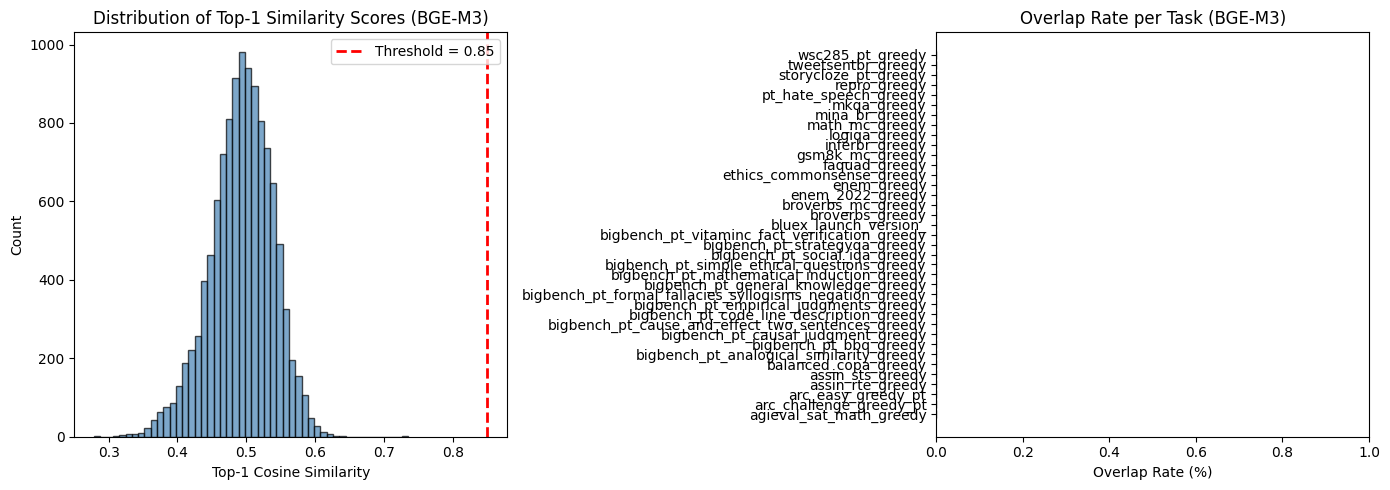

Figure saved to ..\results\runs\bge_m3\figures\overlap_distribution.png


C:\Users\gusth\AppData\Local\Temp\ipykernel_7444\1886789504.py:129: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


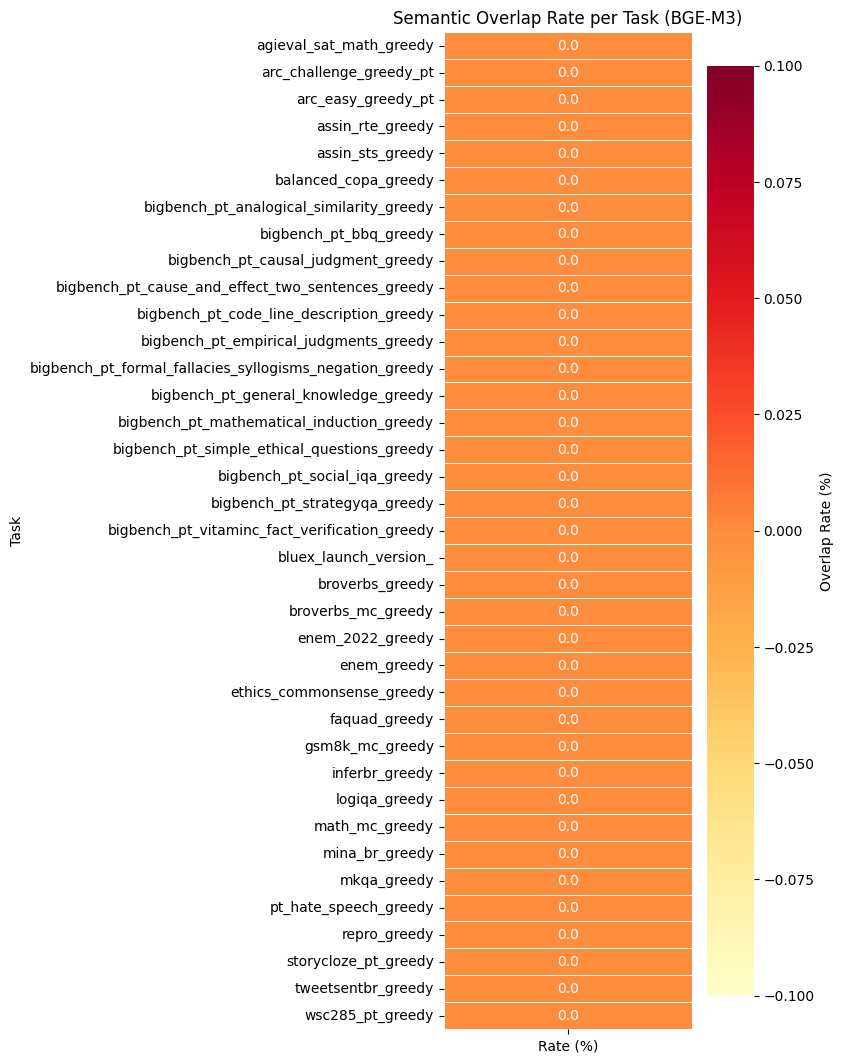

Heatmap saved to ..\results\runs\bge_m3\figures\overlap_heatmap.png

Top-10 most similar matches (for manual inspection):

--------------------------------------------------------------------------------
Task: enem_greedy | Instance: enem_greedy_11 | Similarity: 0.7354
Query:   Ela era linda. Gostava de dançar, fazia teatro em São Paulo e sonhava ser atriz em Hollywood. Tinha 13 anos quando ganhou uma câmera de vídeo — e uma irmã. As duas se tornaram suas companheiras de exp
Matched: Elena. Eu tive um sonho sobre você ontem a noite. Você era macia. Andando nas ruas de Nova Iorque com uma blusa de seda. Eu tento me aproximar... tocar você... sentir o seu cheiro. Mas quando eu vejo,

--------------------------------------------------------------------------------
Task: enem_2022_greedy | Instance: enem_2022_greedy_11 | Similarity: 0.7354
Query:   Ela era linda. Gostava de dançar, fazia teatro em São Paulo e sonhava ser atriz em Hollywood. Tinha 13 anos quando ganhou uma câmera de vídeo —

c:\Users\gusth\Mestrado\projeto\poetaV2-Analysis\training-eval-overlap\env_eval_overlap\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\gusth\.cache\huggingface\hub\models--intfloat--multilingual-e5-large-instruct. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 391/391

Embedding dimension: 1024
Model max_seq_length: 512

Encoding 993 Carolina documents...
Using FAISS CPU index

Encoding chunk 1/1 (0-993)...
  Raw chars: p50=13831, p95=44052, max=84931
  Applying cap: 2,000 chars (987/993 docs truncated)


Batches: 100%|██████████| 125/125 [00:16<00:00,  7.75it/s]


  Chunk encode time: 16.2s
  Index size: 993 vectors

FAISS index built: 993 vectors, dim=1024

Encoding 11,409 PoetaV2 queries...


Batches: 100%|██████████| 1427/1427 [00:47<00:00, 30.31it/s]


Query embeddings shape: (11409, 1024)

Searching FAISS index (top-5)...
Search complete. Scores shape: (11409, 5)

Results: 11409 instances
Overlapping (sim >= 0.85): 3527 (30.91%)

Per-Task Overlap Summary
                                             Task  Total  Overlapping  Rate (%)  Mean Sim  CI Lower  CI Upper
                               broverbs_mc_greedy     27           24     88.89      0.86     74.07    100.00
                               tweetsentbr_greedy    500          385     77.00      0.86     73.20     80.60
                             storycloze_pt_greedy    500          372     74.40      0.86     70.60     78.20
               bigbench_pt_causal_judgment_greedy    190          139     73.16      0.86     66.84     79.47
         bigbench_pt_analogical_similarity_greedy    300          217     72.33      0.86     67.33     77.33
                                   mina_br_greedy    500          360     72.00      0.86     68.00     76.00
                       

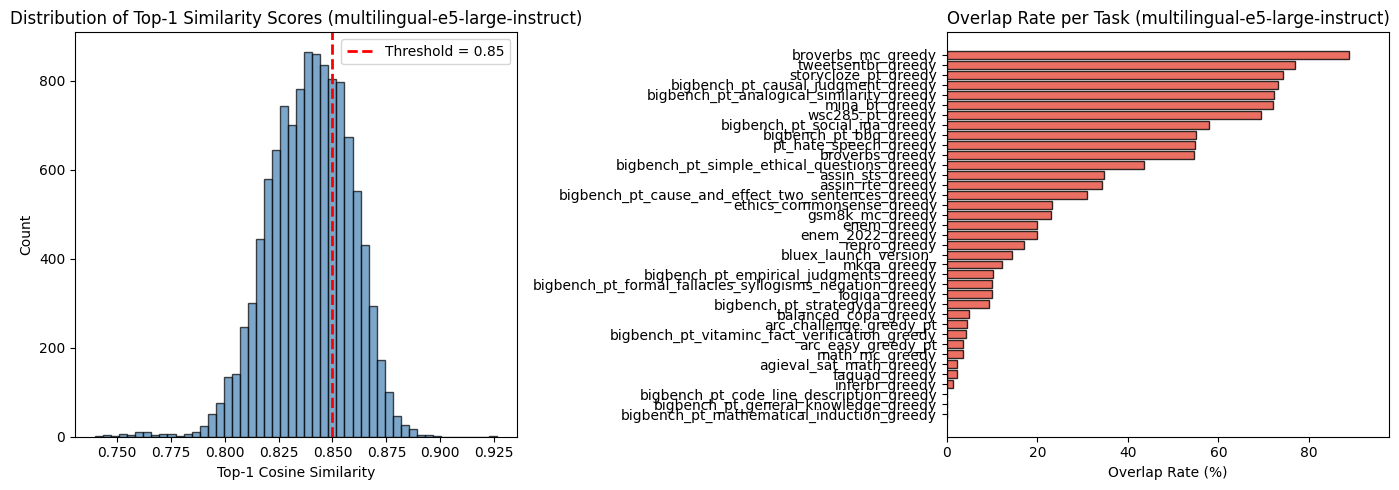

Figure saved to ..\results\runs\multilingual_e5_large_instruct\figures\overlap_distribution.png


C:\Users\gusth\AppData\Local\Temp\ipykernel_7444\1886789504.py:129: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


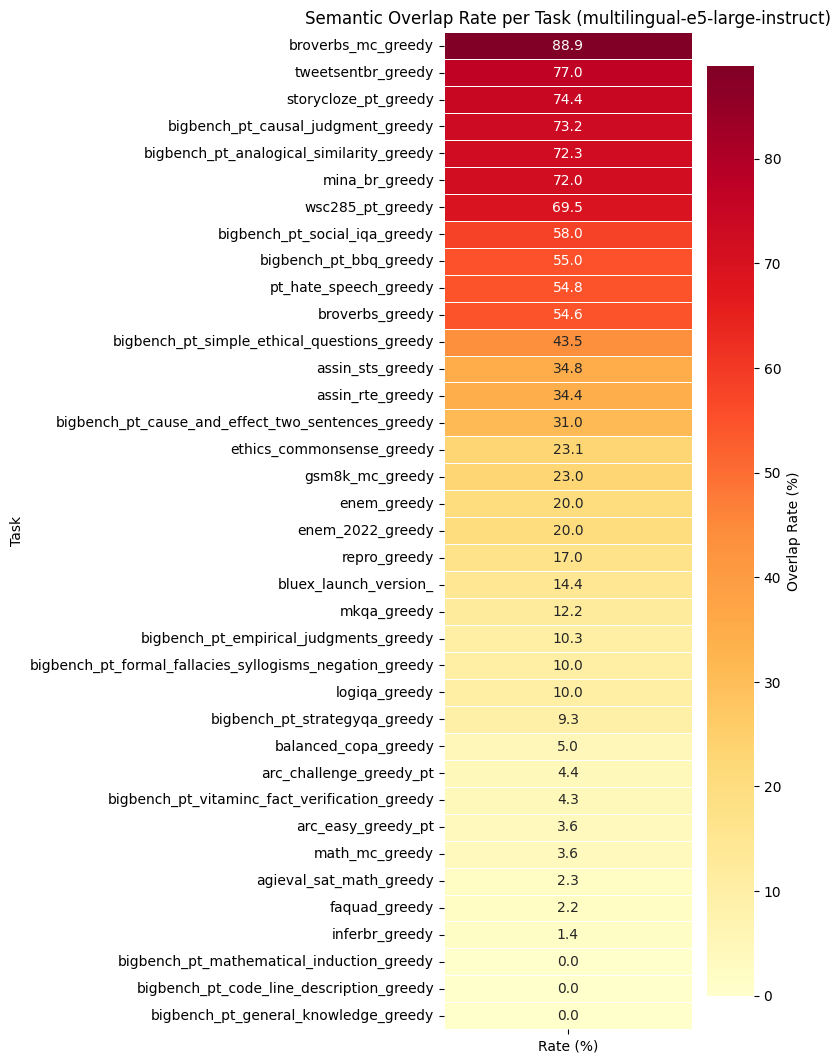

Heatmap saved to ..\results\runs\multilingual_e5_large_instruct\figures\overlap_heatmap.png

Top-10 most similar matches (for manual inspection):

--------------------------------------------------------------------------------
Task: enem_greedy | Instance: enem_greedy_11 | Similarity: 0.9264
Query:   Ela era linda. Gostava de dançar, fazia teatro em São Paulo e sonhava ser atriz em Hollywood. Tinha 13 anos quando ganhou uma câmera de vídeo — e uma irmã. As duas se tornaram suas companheiras de exp
Matched: Elena. Eu tive um sonho sobre você ontem a noite. Você era macia. Andando nas ruas de Nova Iorque com uma blusa de seda. Eu tento me aproximar... tocar você... sentir o seu cheiro. Mas quando eu vejo,

--------------------------------------------------------------------------------
Task: enem_2022_greedy | Instance: enem_2022_greedy_11 | Similarity: 0.9264
Query:   Ela era linda. Gostava de dançar, fazia teatro em São Paulo e sonhava ser atriz em Hollywood. Tinha 13 anos quando ganh

In [14]:
run_artifacts = {}
for profile in RUN_PROFILES:
    artifact = run_profile(profile)
    run_artifacts[profile['slug']] = artifact

print("\nFinished runs:")
for slug, artifact in run_artifacts.items():
    print(f"  - {slug}: {artifact['overlap_count']} overlaps out of {artifact['total_instances']} instances ({artifact['overlap_rate_pct']:.2f}%)")


## Cell 6: Compare Both Runs

This section prints the cross-model comparison inside the notebook and saves a markdown report for later use.


In [15]:
overall_comparison_df = pd.DataFrame([
    {
        'run': artifact['profile']['label'],
        'model_name': artifact['profile']['model_name'],
        'overlaps': artifact['overlap_count'],
        'total_instances': artifact['total_instances'],
        'overlap_rate_pct': artifact['overlap_rate_pct'],
    }
    for artifact in run_artifacts.values()
])
print("Overall comparison:")
print(overall_comparison_df.to_string(index=False, float_format='%.2f'))


Overall comparison:
                           run                              model_name  overlaps  total_instances  overlap_rate_pct
                        BGE-M3                             BAAI/bge-m3         0            11409              0.00
multilingual-e5-large-instruct intfloat/multilingual-e5-large-instruct      3527            11409             30.91


In [16]:
comparison_markdown, task_deltas, common_count, baseline_only_count, candidate_only_count = build_markdown_comparison(run_artifacts)
comparison_dir = RUN_OUTPUT_ROOT / 'comparison'
comparison_dir.mkdir(parents=True, exist_ok=True)
comparison_markdown_path = comparison_dir / 'model_comparison.md'
comparison_markdown_path.write_text(comparison_markdown, encoding='utf-8')

comparison_task_deltas_df = pd.DataFrame(
    task_deltas,
    columns=['task', 'baseline_rate_pct', 'candidate_rate_pct', 'delta_pp'],
)
comparison_task_deltas_df.to_csv(comparison_dir / 'model_comparison_task_deltas.csv', index=False)
overall_comparison_df.to_csv(comparison_dir / 'model_comparison_overall.csv', index=False)

print(comparison_markdown)
print(f"\nComparison markdown saved to {comparison_markdown_path}")
print(f"Agreement counts -> common: {common_count}, baseline_only: {baseline_only_count}, candidate_only: {candidate_only_count}")
print("\nLargest task deltas:")
print(comparison_task_deltas_df.head(10).to_string(index=False, float_format='%.2f'))


# Semantic Run Comparison

## Overall

| Run | Model | Overlaps | Total | Rate (%) |
| --- | --- | ---: | ---: | ---: |
| Baseline | `BAAI/bge-m3` | 0 | 11409 | 0.00 |
| Candidate | `intfloat/multilingual-e5-large-instruct` | 3527 | 11409 | 30.91 |

## Agreement

- Overlaps found by both runs: 0
- Overlaps found only by baseline: 0
- Overlaps found only by candidate: 3527

## Tasks With Largest Rate Changes

| Task | Baseline Rate (%) | Candidate Rate (%) | Delta (pp) |
| --- | ---: | ---: | ---: |
| `broverbs_mc_greedy` | 0.00 | 88.89 | 88.89 |
| `tweetsentbr_greedy` | 0.00 | 77.00 | 77.00 |
| `storycloze_pt_greedy` | 0.00 | 74.40 | 74.40 |
| `bigbench_pt_causal_judgment_greedy` | 0.00 | 73.16 | 73.16 |
| `bigbench_pt_analogical_similarity_greedy` | 0.00 | 72.33 | 72.33 |
| `mina_br_greedy` | 0.00 | 72.00 | 72.00 |
| `wsc285_pt_greedy` | 0.00 | 69.47 | 69.47 |
| `bigbench_pt_social_iqa_greedy` | 0.00 | 58.00 | 58.00 |
| `bigbench_pt_bbq_greedy` | 0.00 | 55.00 | 55.00 |
| `pt_hate_spee

## End State

After `Run all`, the notebook will have executed both multilingual runs, written model-specific outputs under `../results/runs/`, and generated an in-notebook comparison plus a saved markdown comparison report.
